In [1]:
# набор команд для нахождения
# численного решения задачи Коши СДУ (9.37)
# с заданными в момент времени t = 0
# значениями смещений масс колебательной системы
# от времени и их скоростей

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение метода solve_ivp из библиотеки scipy.integrate
from scipy.integrate import solve_ivp

# подключение библиотеки matplotlib
import matplotlib.pyplot as plt

# подключаем функции fft, fftfreq
from scipy.fft import fft, fftfreq


In [2]:
# Ячейка № 3

# задание функции, возвращающей значения
# первых производных СДУ (9.27)


def Deriv(t, x):
    z = np.zeros(2 * N)
    z[0] = x[1]
    z[1] = -Omega[0, 0] * x[0] - Omega[1, 0] * (x[0] - x[2])
    K = 2
    for i in range(N - 2):
        z[K] = x[K + 1]
        z[K + 1] = -Omega[i + 1, i + 1] * (x[K] - x[K - 2]) - Omega[i + 2, i + 1] * (
            x[K] - x[K + 2]
        )
        K = K + 2
    z[2 * N - 2] = x[2 * N - 1]
    z[2 * N - 1] = (
        -Omega[N - 1, N - 1] * (x[2 * N - 2] - x[2 * N - 4])
        - Omega[N, N - 1] * x[2 * N - 2]
    )

    return z

In [3]:
# Ячейка № 4

# задание числа масс
# колебательной системы
N = 4

# задание масс колебательной системы
m = np.array([1, 1, 1, 1])

# задание жесткостей пружин
# колебательной системы
k = np.array([1, 1, 1, 1, 1])

# задание значений смещений масс
# колебательной системы относительно
# их положений равновесия
# в момент времени t = 0
R0 = np.array([0.1, 0, 0, 0])
# задание начальных скоростей
#  масс колебательной системы
# в момент времени t = 0
v0 = np.array([0, 0, 0, 0])

# создание массива Nu и
# сохранение в нем значений
# смещений масс колебательной cистемы
# и их скоростей в момент времени t =0
# Nu[0] = R0[0], Nu[1] = v0[0]
# Nu[2] = R0[1], Nu[3] = v0[1]
# ...
# и т.д.
Nu = np.zeros(2 * N)
for i in range(N):
    Nu[2 * i] = R0[i]
    Nu[2 * i + 1] = v0[i]

# инициализация массива omega,
# используемого для хранения отношений
# жесткостей пружин к массам грузов
omega = np.zeros([N + 1, N])

# инициализация массива omega,
# используемого для хранения
# квадратов частот, входящих
# в характеристическое уравнение (9.6)
Omega = np.zeros([N + 1, N])

# вычисление отношений
# жесткостей пружин к массам грузов
for i in range(N + 1):
    for j in range(N):
        Omega[i, j] = k[i] / m[j]

# задание параметров временной сетки
Tfin = 80
Np = 2**14

Solv = solve_ivp(Deriv, [0, Tfin], Nu, t_eval=np.linspace(0, Tfin, Np))


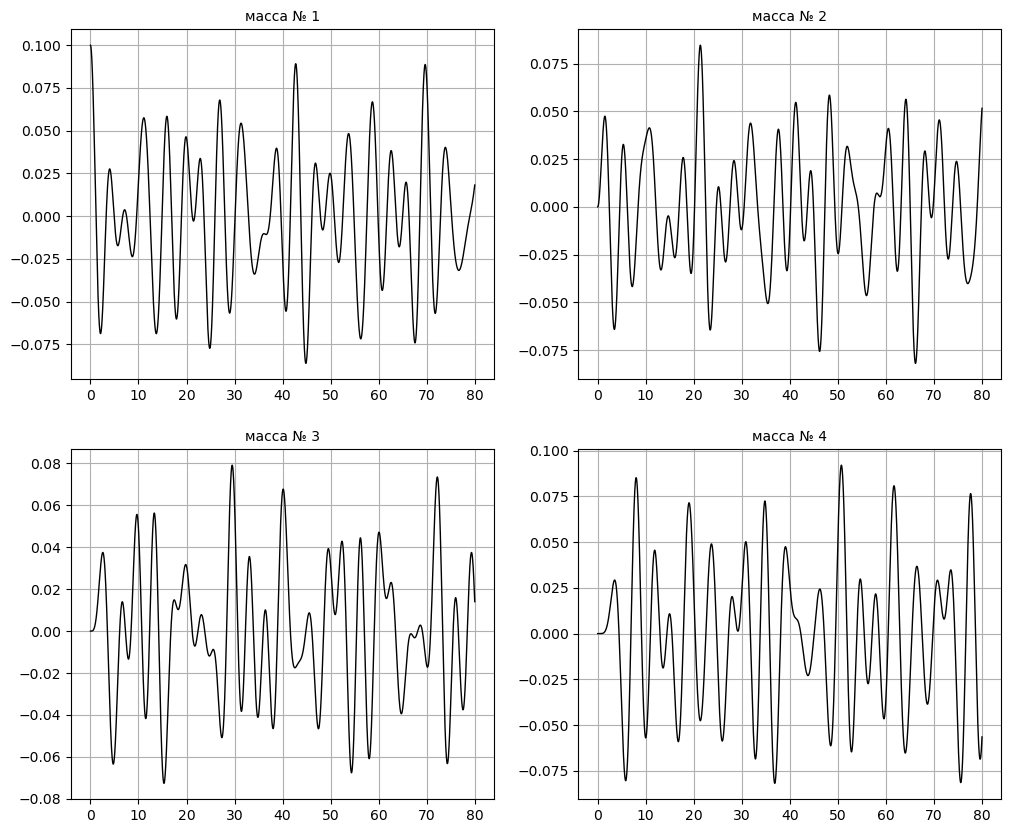

In [4]:
# Ячейка № 5

# визуализация зависимостей смещений
# от положения равновесия
# масс колебательной системы от времени

fig = plt.figure(figsize=(12, 10))

# визуализация зависимости смещения
# от положения равновесия
# массы № 1 колебательной системы от времени
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(Solv.t[:], Solv.y[0, :], "-k", lw=1)
ax1.grid(True)
ax1.set_title("масса № 1", fontsize=10)

# визуализация зависимости смещения
# от положения равновесия
# массы № 2 колебательной системы от времени
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(Solv.t, Solv.y[2, :], "-k", lw=1)
ax2.grid(True)
ax2.set_title("масса № 2", fontsize=10)

# визуализация зависимости смещения
# от положения равновесия
# массы № 3 колебательной системы от времени
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(Solv.t, Solv.y[4, :], "-k", lw=1)
ax3.grid(True)
ax3.set_title("масса № 3", fontsize=10)

# визуализация зависимости смещения
# от положения равновесия
# массы № 4 колебательной системы от времени
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(Solv.t, Solv.y[6, :], "-k", lw=1)
ax4.grid(True)
ax4.set_title("масса № 4", fontsize=10)

plt.show()

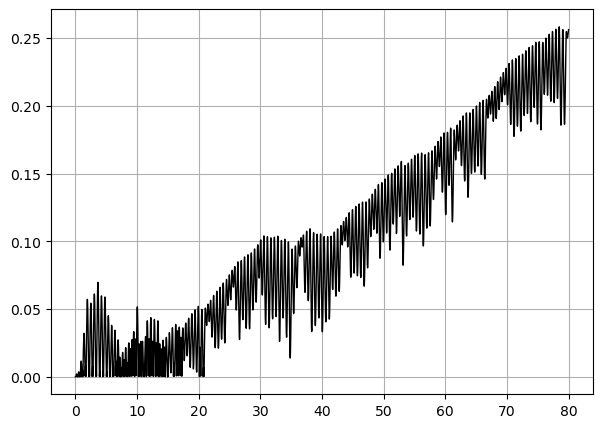

In [5]:
# Ячейка № 6

# вычисление мгновенных значений
# полных энергий масс колебательной системы,
# полной энергии колебательной системы и
# визуализация относительной погрешности
# выполнения закона сохранения энергии
# на основе использования
# численных решений СДУ (9.30)

# инициализация массива E,
# используемого для хранения
# мгновенных значений полной
# энергии масс колебательной системы
Np = len(Solv.t)
E = np.zeros([N, Np])

# вычисление мгновенных значений полной
# энергии масс колебательной системы
# в соответствие с (9.23)
for i in range(Np):
    for j in range(N):
        if j == 0:
            E[j, i] = (
                0.5 * m[j] * Solv.y[2 * j + 1, i] ** 2
                + 0.5 * k[j] * Solv.y[2 * j, i] ** 2
                + 0.25 * k[j + 1] * (Solv.y[2 * j, i] - Solv.y[2 * j + 2, i]) ** 2
            )
        if j == N - 1:
            E[j, i] = (
                0.5 * m[j] * Solv.y[2 * j + 1, i] ** 2
                + 0.5 * k[j + 1] * Solv.y[2 * j, i] ** 2
                + 0.25 * k[j] * (Solv.y[2 * j, i] - Solv.y[2 * j - 2, i]) ** 2
            )
        if (j > 0) & (j < N - 1):
            E[j, i] = (
                0.5 * m[j] * Solv.y[2 * j + 1, i] ** 2
                + 0.25 * k[j] * (Solv.y[2 * j, i] - Solv.y[2 * j - 2, i]) ** 2
                + 0.25 * k[j] * (Solv.y[2 * j, i] - Solv.y[2 * j + 2, i]) ** 2
            )

# вычисление мгновенных значений
# полной энергии колебательной системы
# в соответствие с (9.24)
Efull = np.sum(E, axis=0)

# визуализация абсолютных отклонений с течением времени
# мгновенных значений энергии
# колебательной системы от нее начального значения
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot()
ax.plot(Solv.t[:], abs(Efull[:] - Efull[0]) / Efull[0] * 100, "-k", lw=1)
ax.grid(True)

plt.show()

In [ ]:
# ячейка № 7

# вычисление на основе
# численного решения СДУ (9.30)
# зависимостей нормальных координат
# и их скоростей от времени

# инициализация массива Х,
# используемого для хранения
# мгновенных значений
# зависимостей смещений
# нормальных мод колебательной системы
# от времени
X = np.zeros([Np, N])

# инициализация массива Х,
# используемого для хранения
# мгновенных значений
# зависимостей скорости
# нормальных мод колебательной системы
# от времени
V = np.zeros([Np, N])

# инициализация массива omega,
# используемого для хранения
# матрицы omega, вычисляемой
# в соответствии с (9.8)
omega = np.zeros([N, N])

# вычисление вычисление значений
# элементов матрицы Omega
# в соответствие с (9.8)
for i in range(N):
    if i == 0:
        omega[0, 0] = Omega[0, 0] + Omega[1, 0]
        omega[0, 1] = -Omega[1, 0]
    if i > 0:
        if i < N - 1:
            omega[i, i - 1] = -Omega[i, i]
            omega[i, i] = Omega[i, i] + Omega[i + 1, i]
            omega[i, i + 1] = -Omega[i + 1, i]
        else:
            omega[i, i - 1] = -Omega[i, i]
            omega[i, i] = Omega[i, i] + Omega[i + 1, i]

# вычисление собственных чисел и
# собственных векторов матрицы omеga
Teta, Sigma = np.linalg.eig(omega)

# инициализация массива Teta_M,
# используемого для создания
# диагональной матрицы, в которой
# на главной диагонали размещаются с
# соответствующие собственные числа матрицы B
Teta_M = np.zeros([N, N])

# размещение на главной диагонали матрицы Teta_M
# соответствующих собственных чисел матрицы B
for i in range(N):
    Teta_M[i, i] = np.sqrt(Teta[i])

# вычисление матрицы,
# обратной матрице Sigma
Sx = np.linalg.inv(Sigma)

# перемещение численного
# решения СДУ (9.30) из массива размерностью N x Np
# в массив размерностью Np x N
Y1 = Solv.y.T

# инициализация массива X2,
# используемого для хранения мгновенных значений
# смещений от положения равновесия
# масс колебательной системы
X2 = np.zeros([Np, N])

# инициализация массива V2,
# используемого для хранения мгновенных значений
# скоростей масс колебательной системы
V2 = np.zeros([Np, N])

# перемещение значений координат и
# скоростей масс колебательной системы
# в массивы X2 и V2, соответственно
for i in range(N):
    X2[:, i] = Y1[:, 2 * i]
    V2[:, i] = Y1[:, 2 * i + 1]


# инициализация массива Xn,
# используемого для хранения мгновенных значений
# смещений от положения равновесия
# масс колебательной системы
Xn = np.zeros([Np, N])

# инициализация массива Vn,
# используемого для хранения мгновенных значений
# скоростей масс колебательной системы
Vn = np.zeros([Np, N])

# вычисление мгновенных значений
# координат и скоростей колебательной системы
# в соответствие с (9.31)
for i in range(Np):
    Xn[i, :] = np.dot(Sx, X2[i, :])
    Vn[i, :] = np.dot(Sx, V2[i, :])


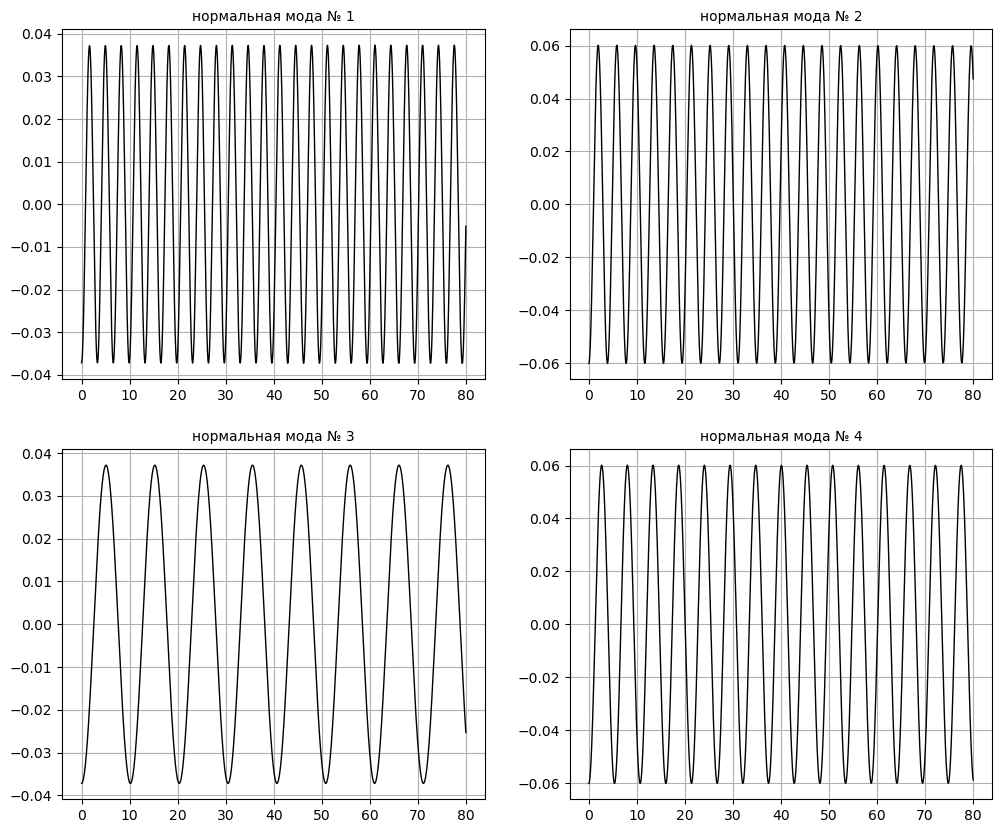

In [7]:
# Ячейка № 8

# визуализация мгновенных значений
# зависимостей координат нормальных мод
# колебательной системы от времени

fig = plt.figure(figsize=(12, 10))

# визуализация мгновенных значений
# координат нормальной моды № 1 от времени
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(Solv.t[:], Xn[:, 0], "-k", lw=1)
ax1.grid(True)
ax1.set_title("нормальная мода № 1", fontsize=10)


# визуализация мгновенных значений
# координат нормальной моды № 2 от времени
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(Solv.t, Xn[:, 1], "-k", lw=1)
ax2.grid(True)
ax2.set_title("нормальная мода № 2", fontsize=10)

# визуализация мгновенных значений
# координат нормальной моды № 3 от времени
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(Solv.t, Xn[:, 2], "-k", lw=1)
ax3.grid(True)
ax3.set_title("нормальная мода № 3", fontsize=10)

# визуализация мгновенных значений
# координат нормальной моды № 4 от времени
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(Solv.t, Xn[:, 3], "-k", lw=1)
ax4.grid(True)
ax4.set_title("нормальная мода № 4", fontsize=10)

plt.show()

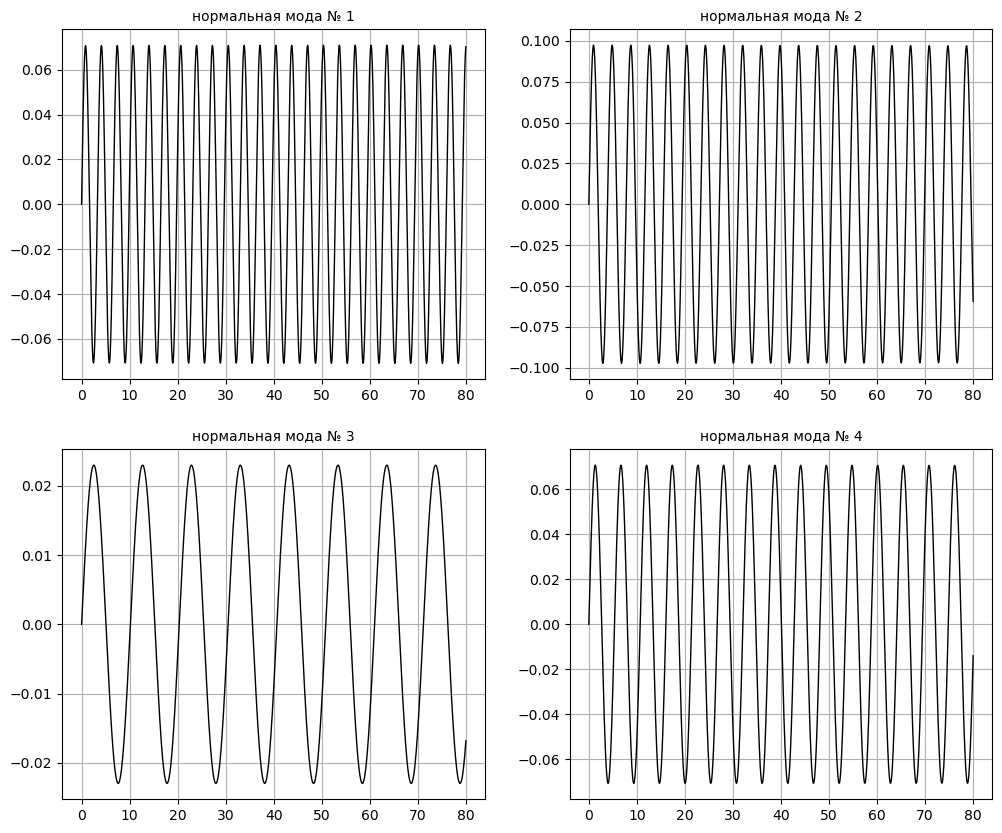

In [8]:
# Ячейка # 9

# визуализация зависимостей скоростей
# мод нормальных колебаний
# изучаемой системы от времени

fig = plt.figure(figsize=(12, 10))

# визуализация мгновенных значений
# зависимости скорости
# нормальной моды колебаний № 1
# от времени
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(Solv.t[:], Vn[:, 0], "-k", lw=1)
ax1.grid(True)
ax1.set_title("нормальная мода № 1", fontsize=10)

# визуализация мгновенных значений
# зависимости скорости
# нормальной моды колебаний № 2
# от времени
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(Solv.t, Vn[:, 1], "-k", lw=1)
ax2.grid(True)
ax2.set_title("нормальная мода № 2", fontsize=10)

# визуализация мгновенных значений
# зависимости скорости
# нормальной моды колебаний № 3
# от времени
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(Solv.t, Vn[:, 2], "-k", lw=1)
ax3.grid(True)
ax3.set_title("нормальная мода № 3", fontsize=10)

# визуализация мгновенных значений
# зависимости скорости
# нормальной моды колебаний № 4
# от времени
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(Solv.t, Vn[:, 3], "-k", lw=1)
ax4.grid(True)
ax4.set_title("нормальная мода № 4", fontsize=10)

plt.show()

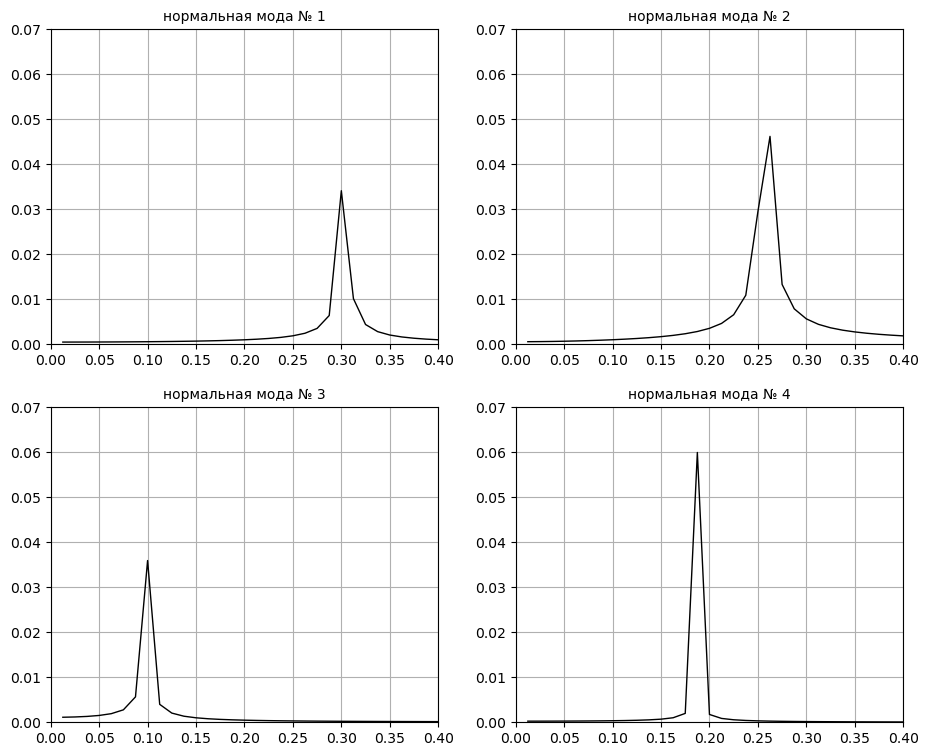

In [ ]:
# Ячейка № 10

# визуализация спектров
# мод нормальных колебаний

Np = len(Solv.t)

# определяем шаг временной сетки,
# в узлах которой вычисляются значения
# анализируемого сигнала
dt = Solv.t[1] - Solv.t[0]

# вычисляем значения комплекснозначных
# коэффициентов ряда Фурье
c1 = fft(Xn[:, 0])
c2 = fft(Xn[:, 1])
c3 = fft(Xn[:, 2])
c4 = fft(Xn[:, 3])

# вычисляем соответствующие значения
# частот спектральных гармоник
Freq = fftfreq(Np, dt)

# задаем число информативных спектральных гармоник
N2 = round((Np - 1) / 2) - 1

# инициализируем массивы, используемые для хранения
# значений  нормированных амплитуд
# информативных спектральных гармоник и
# соответствующих частот
c_R1 = np.zeros(N2)
c_R2 = np.zeros(N2)
c_R3 = np.zeros(N2)
c_R4 = np.zeros(N2)
Freq_R = np.zeros(N2)

# записываем в массивы Freq_R и c_R
# значения циклических частот
# информативных спектральных гармоник
# и соответствующих нормированных амплитуд
for i in range(N2):
    Freq_R[i] = Freq[i + 1]
    c_R1[i] = np.abs(2 * c1[i + 1]) / Np
    c_R2[i] = np.abs(2 * c2[i + 1]) / Np
    c_R3[i] = np.abs(2 * c3[i + 1]) / Np
    c_R4[i] = np.abs(2 * c4[i + 1]) / Np

# визуализация спектров зависимостей
# смещений от положения равновесия
# масс колебательной системы от времени
fig = plt.figure(figsize=(11, 9))

# визуализация спектра зависимости
# смещений от положения равновесия
# массы № 1
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(Freq_R, c_R1, "-k", lw=1)
ax1.set_xlim([0, 0.4])
ax1.set_ylim([0, 0.07])
ax1.grid(True)
ax1.set_title("нормальная мода № 1", fontsize=10)

# визуализация спектра зависимости
# смещений от положения равновесия
# массы № 2
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(Freq_R, c_R2, "-k", lw=1)
ax2.set_xlim([0, 0.4])
ax2.set_ylim([0, 0.07])
ax2.grid(True)
ax2.set_title("нормальная мода № 2", fontsize=10)

# визуализация спектра зависимости
# смещений от положения равновесия
# массы № 3
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(Freq_R, c_R3, "-k", lw=1)
ax3.set_xlim([0, 0.4])
ax3.set_ylim([0, 0.07])
ax3.grid(True)
ax3.set_title("нормальная мода № 3", fontsize=10)

# визуализация спектра зависимости
# смещений от положения равновесия
# массы № 4
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(Freq_R, c_R4, "-k", lw=1)
ax4.set_xlim([0, 0.4])
ax4.set_ylim([0, 0.07])
ax4.grid(True)
ax4.set_title("нормальная мода № 4", fontsize=10)

plt.show()